Logistic Regression Accuracy:
0.9824561403508771

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix
[[41  1]
 [ 1 71]]
Decision Tree Accuracy:
0.9122807017543859

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


Confusion Matrix
[[39  3]
 [ 7 65]]


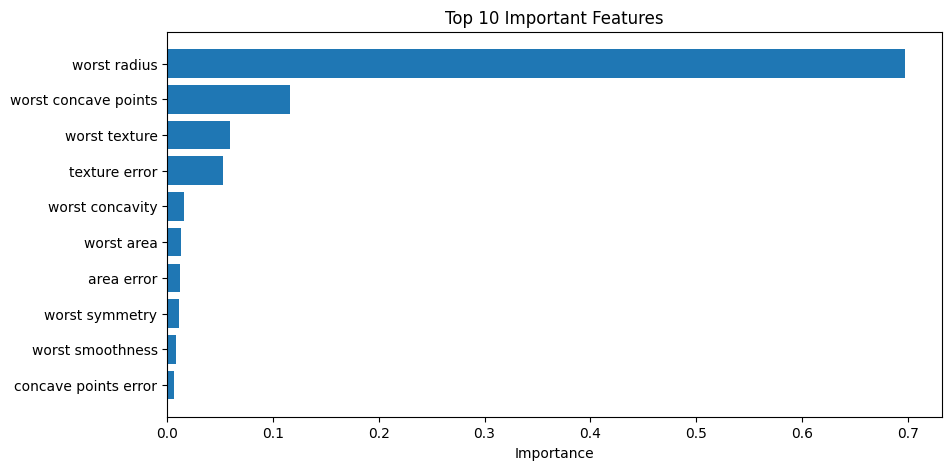

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,

    random_state=42,
    stratify=y
)

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, logistic_predictions))

print("\nClassification Report")
print(classification_report(y_test, logistic_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, logistic_predictions))


tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, tree_predictions))

print("\nClassification Report")
print(classification_report(y_test, tree_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, tree_predictions))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()


# New Section